## PartA_Data structures and functions


In [1]:
# Load the periodic table into a pandas DataFrame.
import pandas as pd
df= pd.read_csv("periodic_table.csv") 

In [2]:
# Dictionnary where the symbols of elements are the keys, and the values are the atmoic mass.
atomic_mass_dict=dict(zip(df["Symbol"],df["AtomicMass"]))

In [ ]:
def mass_calculator(formula:str):
    """
    Calculates the molar mass of a chemical formula without parentheses.

    Parameters
    ----------
    formula : str
        Chemical formula, for example "H2O" or "CH3O".

    Returns
    -------
    float
        Molar mass in g/mol, using the atomic masses provided by periodic_table.csv.

    Notes
    -----
    An index i moves one charecter by one of the given formula.
    If the character is lowercase, the function pairs it with the capital letter to obtain the full symbol.
    Numbers are taken as amount of times the element is present (1 if no number is written).
    Final vlaue obtianed by atomic mass multiplied by the number given.
    Parentheses and hydrate dot notation are not supported.
    """
    total_mass=0
    i = 0

    while i < len(formula):
        symbol = formula[i]
        i += 1

        if i < len(formula) and formula[i].islower():
            symbol += formula[i]
            i += 1

        number = ""
        while i < len(formula) and formula[i].isdigit():
            number += formula[i]
            i += 1

        if number != "":
            count = int(number)
        else:
            count = 1
        total_mass += atomic_mass_dict[symbol] * count

    return total_mass

180.156


In [ ]:
def mass_calculator(formula:str):
    """
    Calculates the molar mass of a formula, including parenthesized groups.

    Parameters
    ----------
    formula : str
        Chemical formula, for example "Ca(OH)2".

    Returns
    -------
    float
        Molar mass in g/mol, using the atomic masses in atomic_mass_dict.

    Notes
    -----
    The index i moves through the formula, identifying element symbols.
    When an opening parenthesis is found, the characters up to the closing parenthesis are stored in a branch.
    Calling mass_calculator(branch) recursively gives the mass of that group.
    Digits after an element or group give its multiplier (the multiplier is 1 if none is present). 
    The mass times this count is added to total_mass.
    Parentheses must be matched. Nested parentheses 
    Hydrate dot notation are not supported by this version.
    """
    total_mass=0
    i = 0

    while i < len(formula):
        symbol = formula[i]
        i += 1
        branch= ""

        if symbol == "(":
            while formula[i] != ")":
                branch += formula[i]
                i += 1
            i += 1    
            mass= mass_calculator(branch)
        else:
            if i < len(formula) and formula[i].islower():
                symbol += formula[i]
                i += 1

            mass = atomic_mass_dict[symbol]

        number = ""
        while i < len(formula) and formula[i].isdigit():
            number += formula[i]
            i += 1

        if number != "":
            count = int(number)
        else:
            count = 1

        total_mass += mass * count

    return total_mass

In [ ]:
def mass_calculator(formula:str):
    """
    Calculates the molar mass of a formula with groups and hydrate water.

    Parameters
    ----------
    formula : str
        Chemical formula, for example "Ca(OH)2" or "CuSO4.5H2O".

    Returns
    -------
    float
        Molar mass in g/mol, using the atomic masses in atomic_mass_dict.

    Notes
    -----
    Element symbols and parenthesized groups are read as in the previous version. 
    A recursive call calculates each group's mass, and digits after an element or group give its multiplier, defaulting to 1.
    When a period is found, the next character is read as the number of water molecules. 
    This count is multiplied by mass_calculator("H2O") and added to total_mass, which is then returned immediately.
    Hydrates must use a period and a single-digit water count, as in "CuSO4.5H2O". 
    The remaining text after the count is not checked, as the function supposes only coordinated water.
    Parentheses must be matched; nested parentheses are not supported.
    """
    total_mass=0
    i = 0

    while i < len(formula):
        symbol = formula[i]
        i += 1
        branch= ""

        if symbol == ".":
            water_number = int(formula[i])
            total_mass += water_number * mass_calculator("H2O")
            return total_mass

        if symbol == "(":
            while formula[i] != ")":
                branch += formula[i]
                i += 1
            i += 1    
            mass= mass_calculator(branch)
        else:
            if i < len(formula) and formula[i].islower():
                symbol += formula[i]
                i += 1

            mass = atomic_mass_dict[symbol]

        number = ""
        while i < len(formula) and formula[i].isdigit():
            number += formula[i]
            i += 1

        if number != "":
            count = int(number)
        else:
            count = 1

        total_mass += mass * count

    return total_mass

249.69100000000003


The periodic table is loaded from `periodic_table.csv` into the pandas DataFrame **df** using `pd.read_csv()`. The columns `Symbol` and `AtomicMass` in the periodic table are used as key and value respectively for the dictionnary `atomic_mass_dict["O"]` using `zip()`, which pairs each element symbol with its atomic mass. 

The first version of **mass_calculator** reads a chemical formula character by character. **total_mass** starts at 0, and the index **i** passes one by one over each charecter of the formula. The current character is stored in **symbol**. If the next character is lowercase, it is added to the symbol, allowing two-letter elements to be read correctly. Using a `while` loop, the digits are collected in the string **number** which allows to count more than one digit. If digits are present, `int(number)` is converted into an integer **count**; otherwise, **count** is set to 1. The atomic mass is multiplied by **count** and added to **total_mass**. 

The second version permits for parenthesized groups to be read correctly. When an opening parenthesis is found, the characters up to the next closing parenthesis are stored in a **branch**. Using a recursive call `mass_calculator(branch)`, the group is calculated using the same function. The digits after the closing parenthesis give the group's multiplier. This version requires matched parentheses and does not support nested groups.

The third version handles additionally hydrate water. When a period is encountered, the next character is converted into **water_number**, the number of water molecules. The function adds `water_number * mass_calculator("H2O")` to **total_mass** and returns immediately. This version requires a period and a single-digit water count. It assumes that the remaining text represents water and nested parentheses are still not supported.


## Part B_Stoichiometry and reaction balancing

### 1. Reaction Balancer Function

In [ ]:
#type:ignore
import numpy as np
from fractions import Fraction
from math import lcm, gcd
from functools import reduce

def balance_reaction(reactants: list, products: list) -> list:
    """
    Finds the stoichiometric coefficients that balance a chemical reaction.

    Parameters:
    reactants : list of str
        Reactant formulas, for example ["C3H8", "O2"].
    products : list of str
        Product formulas, for example ["H2O", "CO2"].

    Returns:
    list of int
        Stoichiometric coefficients, ordered as reactants followed by products.

    Notes:
    Chemical formulas must use correct capitalization, e.g. "Na", not "NA".
    Parentheses and hydrate dot notation are not supported.
    """
    molecules = reactants + products
    atom_count = []
    for molecule in molecules:
        atoms = {}
        i = 0
        while i < len(molecule):
            element = molecule[i]
            i += 1
            if i < len(molecule) and molecule[i].islower():
                element += molecule[i]
                i += 1
            number = ""
            while i < len(molecule) and molecule[i].isdigit():
                number += molecule[i]
                i += 1
            if number == "":
                count = 1
            else:
                count = int(number)
            if element in atoms:
                atoms[element] += count
            else:
                atoms[element] = count
        atom_count.append(atoms)

    elements = []
    for atoms in atom_count:
        for element in atoms:
            if element not in elements:
                elements.append(element)

    A = np.zeros((len(elements), len(molecules)))

    for i, element in enumerate(elements):
        for j, atoms in enumerate(atom_count):
            A[i, j] = atoms.get(element, 0)
            if j >= len(reactants):
                A[i, j] *= -1

    U, S, Vh = np.linalg.svd(A)

    coefficients = Vh[-1]
    coefficients = coefficients / coefficients[0]

    fractions = [Fraction(float(c)).limit_denominator(10000)
             for c in coefficients]

    denominator = lcm(*(f.denominator for f in fractions))
    integers = [int(f * denominator) for f in fractions]

    divisor = reduce(gcd, integers)
    return [c // divisor for c in integers]

    

print(balance_reaction(["C3H8", "O2"], ["H2O", "CO2"]))
print(balance_reaction(["KMnO4", "HCl"], ["KCl", "MnCl2", "Cl2", "H2O"]))
print(balance_reaction(["HCl", "K2Cr2O7"], ["KCl", "CrCl3", "Cl2", "H2O"]))










    


    


   

[1, 5, 4, 3]
[2, 16, 2, 2, 5, 8]
[14, 1, 2, 2, 3, 7]


The lists `reactants` and `products` are combined into `molecules`. Each formula is parsed character by character to count atoms per element. These counts are stored in a dictionary called `atoms`, which is appended to the list `atom_count` for each molecule (e.g. `"C3H8"` → `{"C": 3, "H": 8}`).

Matrix `A` has one row per element and one column per molecule, with positive reactant counts and negative product counts. The `@` operator performs matrix multiplication: for a coefficient vector `x`, `A @ x` computes the difference in atom counts between the two sides for each element. Therefore, `A @ x = 0` expresses conservation of atoms, meaning that `x` must lie in the null space of `A`.

We used the Singular Value Decomposition (SVD) method to find the stoichiometric coefficients. `np.linalg.svd(A)` returns `U`, `S`, and `Vh`, with the singular values in `S` sorted in decreasing order. Assuming the null space of `A` has dimension 1, the last row, `Vh[-1]`, gives a null-space vector within numerical precision. Its entries are the relative stoichiometric coefficients, up to scale and sign. Dividing by `coefficients[0]` makes the first coefficient equal to 1 while preserving their ratios.

Each coefficient is approximated by a fraction using `Fraction(...).limit_denominator(10000)`. The function `lcm()` finds the least common multiple of the denominators, and multiplying by it turns the fractions into integers. Finally, `reduce(gcd, integers)` finds their greatest common divisor. Dividing by it gives the smallest whole-number coefficients, returned as reactants followed by products. For example, `[1, 0.2, 0.8, 0.6]` becomes `[5, 1, 4, 3]`.

## Part C_Simulation /Modelling

### 1. Monte Carlo \pi estimate

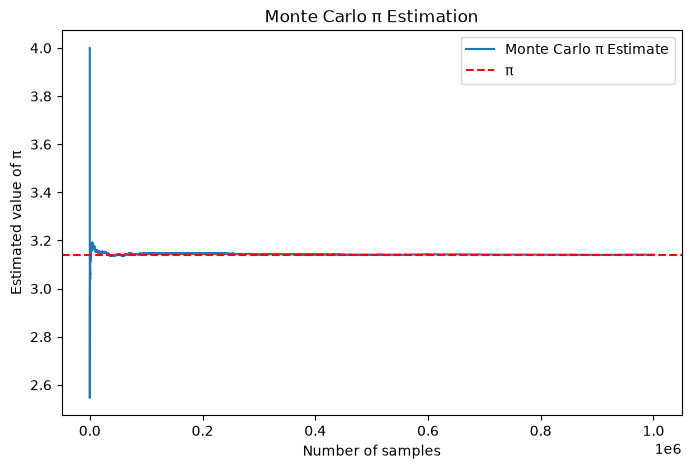

The value of pi estimated with N=1000000 is: 3.141032
Error: 0.0005606535897930698


In [2]:
#type:ignore
import numpy as np
import matplotlib.pyplot as plt 

def estimate_pi(N):
    x = np.random.uniform(-1, 1, N)
    y = np.random.uniform(-1, 1, N)

    distance = np.sqrt(x**2 + y**2)

    ins = distance <= 1

    pi_estimates = 4 * np.cumsum(ins) / np.arange(1, N + 1)

    
    pi_estimate = pi_estimates[-1]

    return pi_estimate, pi_estimates


N = 1000000

pi_value, pi_values = estimate_pi(N)


plt.figure(figsize=(8, 5))

plt.plot(
    range(1, N + 1),
    pi_values,
    label="Monte Carlo π Estimate"
)

plt.axhline(
    y=np.pi,
    color="red",
    linestyle="--",
    label="π"
)

plt.xlabel("Number of samples")
plt.ylabel("Estimated value of π")
plt.title("Monte Carlo π Estimation")
plt.legend()
plt.show()

print(f"The value of pi estimated with N={N} is: {pi_value}")
print(f"Error:", abs(np.pi-pi_value))


### Explanations of the code

Two arrays, **x** and **y**, are created, and both contain **N values between -1 and 1**. A third array, called **distance**, contains the distance of each point \((x,y)\) from the origin.

**ins** is a Boolean array containing only `True` or `False`, depending on whether the distance of each point contained in **distance** is smaller than or equal to 1. Therefore, `True` means that the point is inside the unit circle.

**pi_estimates** is an array containing an estimate of π after each point. It is calculated using **np.cumsum()**, which creates an array containing the cumulative number of `True` values in **ins**. For example, if `ins = [True, False, False, True, ...]`, then `np.cumsum(ins)` gives `[1, 1, 1, 2, ...]`, since `True` is treated as 1 and `False` as 0.

The values of this cumulative sum are multiplied by 4 and divided by the corresponding values in **np.arange(1, N+1)**, which gives `[1, 2, 3, 4, ..., N]`. This gives the estimated value of π after each additional sample.

Finally, **pi_estimate** is taken as the last value of the **pi_estimates** array, which corresponds to the final estimate of π after all N samples have been considered.

Working with **pi_estimates** was convenient because we could directly use the values in this array to plot the estimated value of π as a function of the number of samples.




### 2. Chemistry inspired Monte Carlo

Number of collisions occuring: 1000
Energie of each collision: [ 6.87883705  9.23813625 79.36928345 68.20088267 69.17389929 64.41816561
 86.14484991 54.63346624  2.833559   94.01031988 71.3905972  62.65212075
 11.63092072 82.89565013 66.0420713  71.00765028 40.03919169 56.16850275
 51.44842745 74.95942141 72.3344708  56.61051592 34.91273336 56.37641618
 37.42065403 17.4559627  92.0010681  44.40708933 96.71419118 96.37392102
 76.90456407 28.49995896 70.94796994 23.49310634 45.39038634  7.15255958
 49.26199486 25.37621825 92.82702368 76.73826288 17.51912276 23.24252602
 81.40235341 33.25636741 78.50076756 88.89458421 15.77730392 44.42910611
 70.61084557 26.5873412  26.69405874 65.07370306 85.9162796  64.19635927
 58.23013084 36.83797915 13.43138808 89.11518061 43.67767246 26.15301534
 55.16761304 78.39989691 75.93405315 56.14027728 24.62466397 23.05070882
 78.900704   38.1370984  22.20183384 66.64948255 53.71695799 48.63085616
 45.58322239 74.83797952 78.76879596  9.27017883 33.59285422 

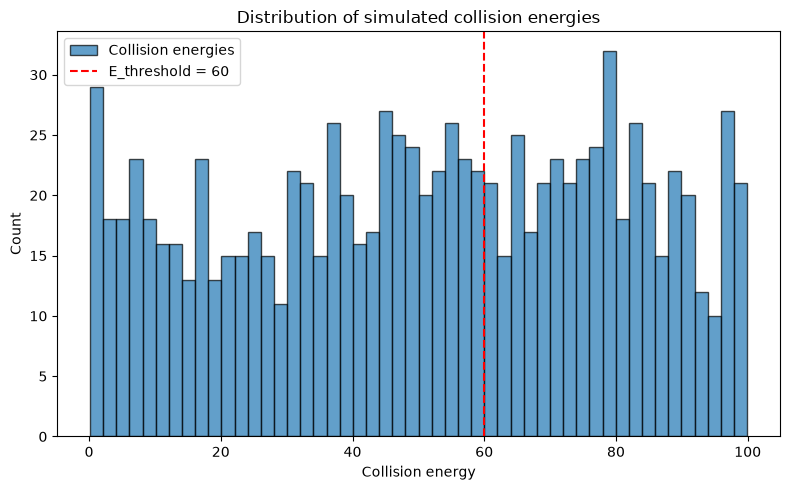

In [ ]:

def simulate_collision(M, threshold):
    collision = np.arange(M)
    energy = np.random.uniform(0, 100, M)

    reacting_collision = np.sum(energy > threshold)
    reaction_probability = reacting_collision/M

    return energy, reacting_collision, reaction_probability

M = 1000
threshold = 60

energy, reacting_collision, reaction_probability = simulate_collision(M, threshold)

print("Number of collisions occuring:", M)
print("Energie of each collision:", energy)
print("Number of collisions exceeding the threshold", reacting_collision)
print("Probability that a reaction occurs:", reaction_probability)

"""
Not mandatory,
but we propose a histogram of the simulated collision energies,
with the activation threshold marked, to visualize what fraction
of collisions exceed it and therefore react.
"""
plt.figure(figsize=(8, 5))

plt.hist(
    energy,
    bins=50,
    alpha=0.7, 
    edgecolor='black',
    label="Collision energies"
)

plt.axvline(threshold, color='red', linestyle='--',
                label=f'E_threshold = {threshold}')
plt.xlabel('Collision energy')
plt.ylabel('Count')
plt.title('Distribution of simulated collision energies')
plt.legend()
plt.tight_layout()

plt.show()




    

### Explanations of the code

The array **collision** is not necessary for the proper functioning of the function, but it allows us to represent the \(M\) simulated collisions.

The array **energy** assigns a random energy between 0 and 100 to each of the \(M\) collisions.

**reacting_collision** gives the number of collisions leading to a reaction by counting the number of collisions that have an energy above the fixed threshold. The expression `energy > threshold` creates a Boolean array containing `True` for collisions exceeding the threshold and `False` otherwise. Using `np.sum()` then counts the number of `True` values.

**reaction_probability** calculates the fraction of collisions that lead to a reaction by dividing the number given by **reacting_collision** by \(M\), the total number of collisions. This fraction is used as an estimate of the reaction probability.
